### Introdução

O conjunto de dados Global Data on Sustainable Energy, disponibilizado no Kaggle, reúne informações detalhadas sobre consumo energético, fontes renováveis, emissões de CO₂, acesso à eletricidade e indicadores econômicos para países de todo o mundo. Esses dados são fundamentais para o monitoramento do progresso em sustentabilidade energética, planejamento de políticas públicas e análise comparativa entre diferentes regiões e faixas de renda.

A natureza quantitativa dessas informações permite a aplicação de métodos estatísticos adequados para dados de contagem, com destaque para os Modelos Lineares Generalizados (GLM), que possibilitam investigar fatores associados ao número de projetos ou eventos relacionados à energia renovável implementados em cada país.

### O Banco de Dados

O banco de dados contém registros anuais agregados por país, contemplando variáveis como população, consumo total de energia, consumo de energia renovável, emissões de CO₂, acesso à eletricidade, intensidade energética e PIB. Também inclui informações categóricas sobre região geográfica e faixa de renda, permitindo comparações espaciais e socioeconômicas.

Essa estrutura possibilita a **análise de contagens de eventos relacionados à energia, como o número de projetos de energia renovável implementados por país/ano**, bem como a investigação de padrões de consumo e emissão de carbono em diferentes contextos socioeconômicos e geográficos.

### Modelagem Estatística (GLM)

A variável resposta principal — número de projetos de energia renovável implementados — é caracterizada como dado de contagem, assumindo valores inteiros não negativos. Nesse contexto, a análise é conduzida por meio de Modelos Lineares Generalizados (GLM), permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas, como população, consumo energético, emissões de CO₂, acesso à eletricidade, PIB, região e faixa de renda.

Inicialmente, pode-se empregar a distribuição Poisson, adequada para modelagem de contagens sob a suposição de igualdade entre média e variância. Contudo, devido à heterogeneidade entre países e à variabilidade observada nos dados de energia, é comum a ocorrência de sobredispersão, tornando a Binomial Negativa uma alternativa mais apropriada. Essas abordagens possibilitam a identificação de fatores associados à implementação de projetos de energia renovável e a avaliação de diferenças entre países e regiões

In [154]:
import pandas as pd

df= pd.read_csv(
    "global-data-on-sustainable-energy (1).csv",
    sep=",",
    encoding="latin1",
    low_memory=False
)


In [155]:
import numpy as np

# Renomear colunas (português, mas fiel ao original)
df = df.rename(columns={
    "Entity": "regiao",
    "Access to electricity (% of population)": "pct_acesso_eletricidade",
    "Primary energy consumption per capita (kWh/person)": "consumo_energia_primaria_kwh_per_capita",
    "Renewables (% equivalent primary energy)": "pct_energia_renovaveis_primaria",
    "Value_co2_emissions_kt_by_country": "co2_emissoes_tm_per_capita",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "intensidade_energia_mj_por_pib_ppp", 
    "Renewable-electricity-generating-capacity-per-capita": "capacidade_eletrica_renovavel_per_capita", #per_capita ou por_pessoa é mesma coisa
    "gdp_per_capita": "pib_per_capita",
    "Density\\n(P/Km2)": "densidade_populacional"
})

# Seleção de variáveis
cols = [
    "regiao",
    "pib_per_capita",
    "consumo_energia_primaria_kwh_per_capita",
    "pct_energia_renovaveis_primaria",
    "co2_emissoes_tm_per_capita",
    "pct_acesso_eletricidade",
    "intensidade_energia_mj_por_pib_ppp",
    "capacidade_eletrica_renovavel_per_capita",
    "densidade_populacional"
]

df['densidade_populacional'] = df['densidade_populacional'].str.replace(',', '').astype(float)

# Conversão de tipos
df_energy_filtrado = df[cols].copy()
df_energy_filtrado = df_energy_filtrado.astype({
    "pib_per_capita": float,
    "consumo_energia_primaria_kwh_per_capita": float,
    "pct_energia_renovaveis_primaria": float,
    "co2_emissoes_tm_per_capita": float,
    "pct_acesso_eletricidade": float,
    "intensidade_energia_mj_por_pib_ppp": float,
    "regiao": "category",
    "capacidade_eletrica_renovavel_per_capita": float,
})

# Remover outros NA
df_energy_filtrado = df_energy_filtrado.dropna()
df_energy_filtrado.head()



,regiao,pib_per_capita,consumo_energia_primaria_kwh_per_capita,pct_energia_renovaveis_primaria,co2_emissoes_tm_per_capita,pct_acesso_eletricidade,intensidade_energia_mj_por_pib_ppp,capacidade_eletrica_renovavel_per_capita,densidade_populacional
42,Algeria,1765.027146,9746.524,0.053235,80050.00000,98.97310,4.18,8.91,18.0
43,Algeria,1740.606654,9961.640,0.065218,78650.00000,98.96687,4.07,8.79,18.0
44,Algeria,1781.828908,10180.350,0.051677,82400.00153,98.95306,4.12,8.68,18.0
45,Algeria,2103.381291,10510.461,0.228104,88190.00244,98.93401,4.08,8.57,18.0
46,Algeria,2610.185422,10759.022,0.206787,89489.99786,98.91208,3.96,8.46,18.0


In [ ]:
print(df_energy_filtrado.columns.tolist())

Os dados apresentados na tabela a seguir descrevem as variáveis disponíveis no conjunto de dados **Global Data on Sustainable Energy (2000-2020)**. Cada variável possui uma classificação quanto ao tipo dado, natureza e seu uso potencial em análises baseadas em Modelos Lineares Generalizados (GLM). Essas informações são essenciais para compreender a estrutura do banco de dados e orientar as análises subsequentes.

| Variável                                          | Tipo de dado       | Natureza     | Característica                                                                                                                                                 |
| ------------------------------------------------- | ------------------ | ------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **regiao**                                        | Categórica nominal | Qualitativa  | Região geográfica do país; criar dummies para modelar diferenças regionais                                                                                     |
| **pib_per_capita**                                | Contínua           | Quantitativa | Produto Interno Bruto per capita do país (em US$); indica o nível de riqueza média da população                                                                |
| **consumo_energia_primaria_kwh_per_capita**       | Contínua           | Quantitativa | Consumo total de energia primária per capita (em kWh); indica a carga energética individual, pode afetar eventos relacionados à energia                        |
| **pct_energia_renovaveis_primaria**               | Contínua           | Quantitativa | Percentual do consumo de energia primária proveniente de fontes renováveis; uso direto ou log-transformada                                                     |
| **co2_emissoes_tm_per_capita**                    | Contínua           | Quantitativa | Emissões de CO₂ per capita (em toneladas métricas); log-transformar se houver valores muito altos                                                              |
| **pct_acesso_eletricidade**                       | Contínua           | Quantitativa | Percentual da população com acesso à eletricidade; indicador de cobertura energética nacional                                                                  |
| **intensidade_energia_mj_por_pib_ppp**            | Contínua           | Quantitativa | Quantidade de energia (em megajoules) usada para gerar 1 dólar de riqueza, ajustada pela paridade do poder de compra; quanto menor, mais eficiente é o país   |
| **capacidade_eletrica_renovavel_per_capita**      | Contínua           | Quantitativa | Capacidade instalada de geração elétrica renovável per capita; indica o nível de infraestrutura limpa disponível por habitante                                 |
| **densidade_populacional**                        | Contínua           | Quantitativa | Número de habitantes por km²; pode ser usada como **offset** log(densidade) para modelar padrões de consumo e acesso por concentração geográfica               |


### Importância das Medidas Descritivas

As medidas descritivas são utilizadas para caracterizar a estrutura das variáveis do estudo. Variáveis numéricas, como população, consumo total de energia, consumo de energia renovável, emissões de CO₂ e PIB, são descritas por medidas de tendência central, dispersão e amplitude, permitindo resumir sua distribuição entre os países.

Variáveis categóricas, como região geográfica e faixa de renda, são descritas por meio de frequências absolutas e relativas, possibilitando a compreensão da distribuição das categorias. Essas descrições fornecem uma visão inicial dos padrões de implementação de projetos de energia renovável e permitem identificar possíveis agrupamentos ou desigualdades entre países e regiões.

In [92]:
# Estatísticas descritivas básicas
tabela_descritiva = df_energy_filtrado[cols].describe().round(2)

# Aplicando estilo
tabela_descritiva.style.format("{:.2f}") \
                       .set_caption("Estatísticas Descritivas com Skewness e Kurtosis") 
                       #.background_gradient(_


,pib_per_capita,consumo_energia_primaria_kwh_per_capita,pct_energia_renovaveis_primaria,co2_emissoes_tm_per_capita,pct_acesso_eletricidade,intensidade_energia_mj_por_pib_ppp,capacidade_eletrica_renovavel_per_capita,densidade_populacional
count,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00
mean,10946.85,41339.02,8.17,436212.55,93.60,6.28,98.65,428.26
std,14969.42,53861.94,10.80,1423712.83,11.35,5.01,121.47,1467.55
min,383.34,1053.62,0.00,10200.00,32.00,1.76,0.00,7.00
25%,2212.11,8014.11,0.23,49027.50,93.69,3.43,10.44,26.00
50%,5666.00,18205.21,3.56,96350.00,99.09,4.78,58.36,93.00
75%,11210.37,42560.49,11.69,236567.49,100.00,6.78,132.96,248.00
max,85075.99,262585.70,47.30,10707219.73,100.00,32.57,684.92,8358.00


### Entendo a distribuição dos dados via Pair plot

O pair plot é uma ferramenta gráfica que permite visualizar a distribuição de variáveis numéricas e as relações entre elas. Ele possibilita observar a dispersão dos dados, a presença de valores atípicos e possíveis padrões de associação entre as variáveis.

No contexto dos dados analisados, pode ser utilizado para explorar as variáveis, fornecendo insights sobre variação, tendência e possíveis relações estruturais. A priori, optamos por realizar a transformação logarítmica.

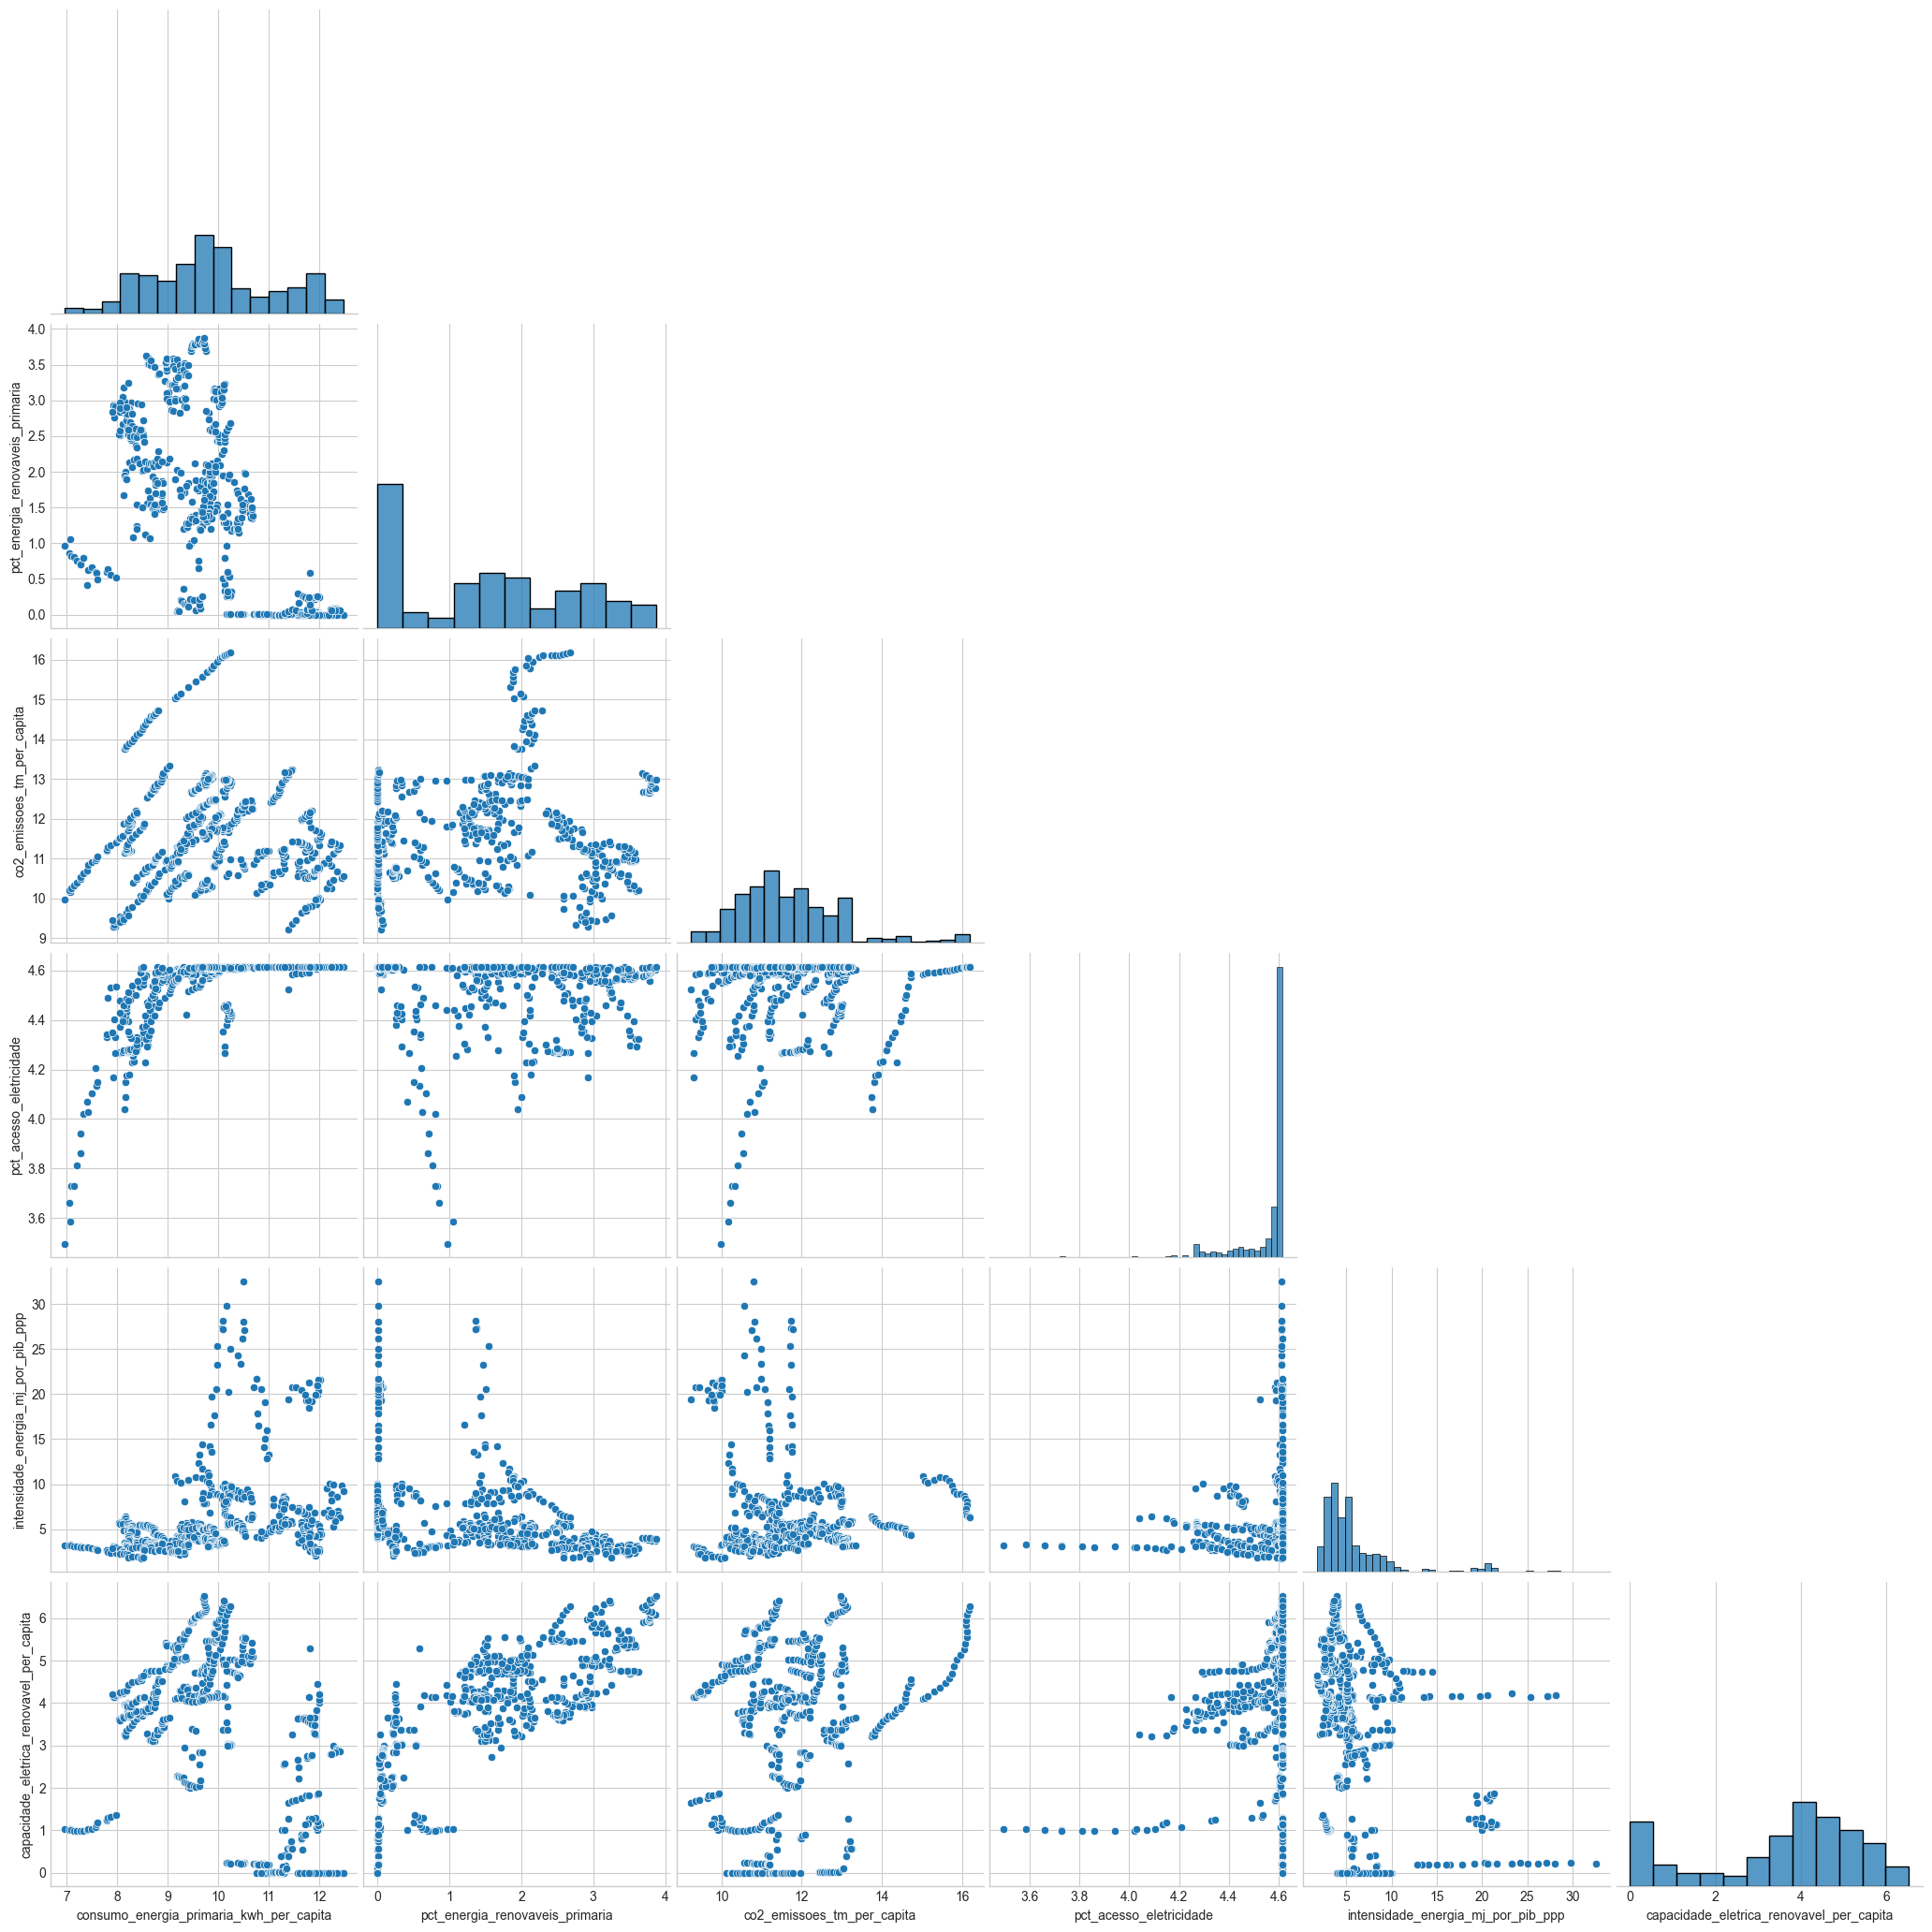

In [156]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


# y = df_energy_filtrado["intensidade_energia_mj_por_pib_ppp"]
# X = df_energy_filtrado.drop(columns=["intensidade_energia_mj_por_pib_ppp"])
# colunas_winsor = X.select_dtypes(include="number").columns
# for c in colunas_winsor:
#     q_low = X[c].quantile(0.05)
#     q_high = X[c].quantile(0.95)
#     X[c] = X[c].clip(lower=q_low, upper=q_high)
# df_energy_filtrado = pd.concat([X, y], axis=1)

sns.pairplot(df_energy_filtrado, # Variáveis que queremos no pairplot
vars = cols[2:8],
    corner=True,
    height=3.5   # aumenta tamanho de cada gráfico
    )

### Relações lineares entre variáveis numéricas
 A matriz de correlação de Spearman entre as variáveis numéricas do dataset. O objetivo é identificar relações lineares fortes que possam informar próximas etapas (e.g., seleção de variáveis, multicolinearidade, ou insights de causa/efeito possível).

Pontos importantes:
- O coeficiente de Pearson varia de -1 a 1; 1 indica correlação positiva perfeita, -1 correlação negativa perfeita, e 0 nenhuma correlação linear.
- Correlação não implica causalidade: use estes resultados apenas como sinalizadores.
- Atenção a colinearidade: variáveis fortemente correlacionadas podem distorcer modelos que supõem independência entre variáveis (e.g., regressão).

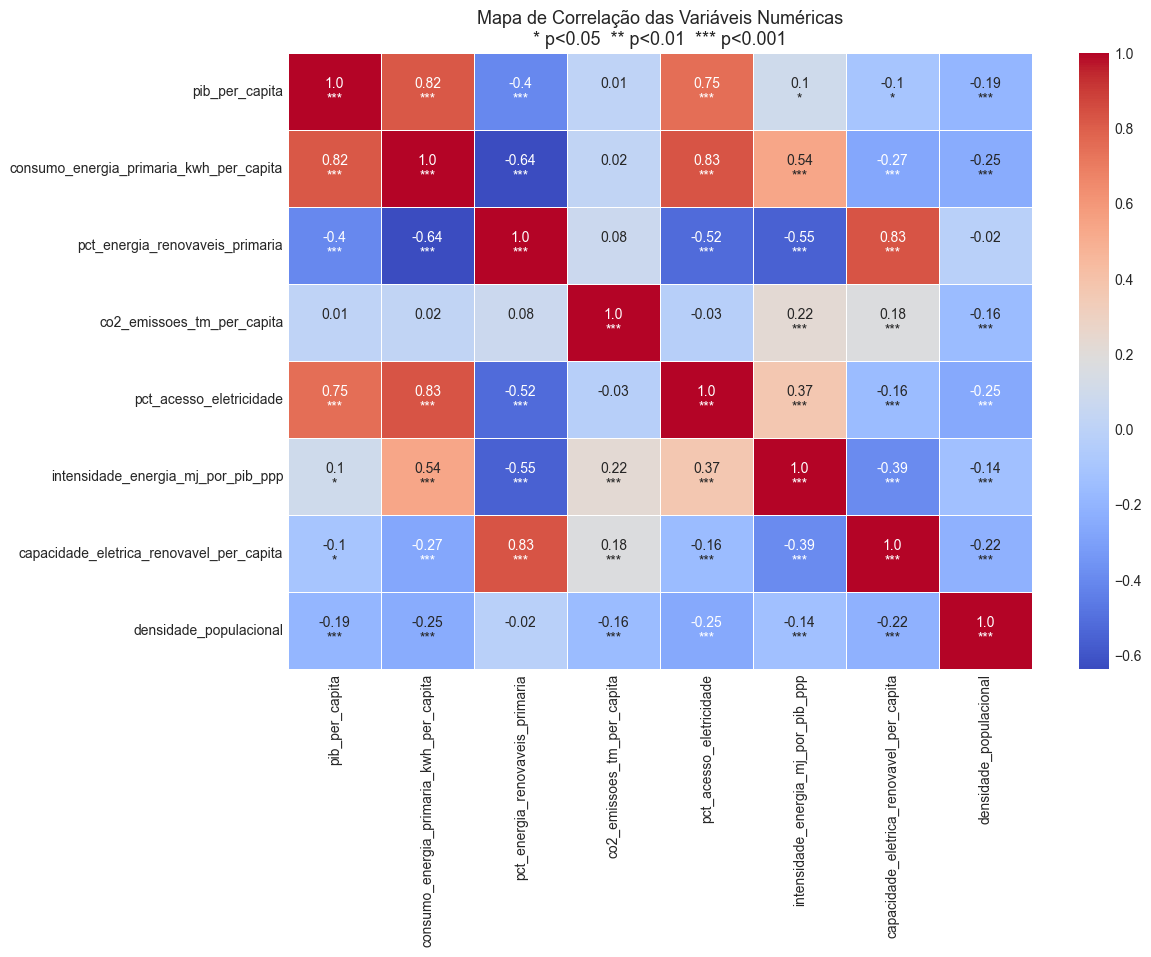

In [108]:
from scipy.stats import spearmanr
import numpy as np

# Calcula correlação e p-valores
corr = df_energy_filtrado.corr(numeric_only=True, method="spearman")
df_num = df_energy_filtrado.select_dtypes(include="number")
pval = pd.DataFrame(
    spearmanr(df_num, nan_policy="omit").pvalue,
    columns=corr.columns, index=corr.index
)

# Cria anotações com asteriscos
def significancia(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot = corr.round(2).astype(str) + "\n" + pval.map(significancia)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=annot, cmap='coolwarm', fmt='', linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Numéricas\n* p<0.05  ** p<0.01  *** p<0.001", fontsize=13)
plt.show()

Diante das variáveis selecionadas, optou-se por prosseguir as análises sem as variáveis **pct_acesso_eletricidade**, **consumo_energia_primaria_kmh_per_capita**,**pct_energia_renovaveis_primamaria** uma vez que ela se encontram fortemente correlacionadas. Considerando essa elevada correlação, manteve-se no modelo apenas as demais variáveis, a fim de evitar problemas de multicolinearidade e possíveis distorções nas estimativas.

In [157]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

colunas_x = [
    "pib_per_capita",
    "consumo_energia_primaria_kwh_per_capita",
    "pct_energia_renovaveis_primaria",
    "co2_emissoes_tm_per_capita",
    "pct_acesso_eletricidade",
    "capacidade_eletrica_renovavel_per_capita",
    "densidade_populacional"
]

X = df_energy_filtrado[colunas_x]
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))


                                   Variável          VIF
0                                     const  1793.810378
2   consumo_energia_primaria_kwh_per_capita     7.045758
3           pct_energia_renovaveis_primaria     4.913612
1                            pib_per_capita     4.039970
6  capacidade_eletrica_renovavel_per_capita     3.732942
5                   pct_acesso_eletricidade     2.422639
7                    densidade_populacional     1.283355
4                co2_emissoes_tm_per_capita     1.103840


In [158]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

df_energy_filtrado = df_energy_filtrado.reset_index(drop=True)
formula="""
    intensidade_energia_mj_por_pib_ppp ~
    pct_energia_renovaveis_primaria +
    pib_per_capita +
    capacidade_eletrica_renovavel_per_capita +
    pct_acesso_eletricidade +
    densidade_populacional +
    co2_emissoes_tm_per_capita
    """
# Exemplo de modelo GLM Gamma
modelo = smf.glm(
    formula,
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

# Resumo do modelo
modelo.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                  620
Model:                                            GLM   Df Residuals:                      613
Model Family:                                   Gamma   Df Model:                            6
Link Function:                                    Log   Scale:                         0.21404
Method:                                          IRLS   Log-Likelihood:                -1391.3
Date:                                seg, 23 fev 2026   Deviance:                       116.03
Time:                                        14:58:09   Pearson chi2:                     131.
No. Iterations:                                    24   Pseudo R-squ. (CS):             0.6170
Covariance Type:                            nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -2.5491      0.775     -3.289      0.001      -4.068      -1.030
pct_energia_renovaveis_primaria             -0.3396      0.030    -11.263      0.000      -0.399      -0.280
pib_per_capita                              -0.2477      0.021    -11.927      0.000      -0.288      -0.207
capacidade_eletrica_renovavel_per_capita    -0.0251      0.019     -1.305      0.192      -0.063       0.013
pct_acesso_eletricidade                      1.5324      0.179      8.556      0.000       1.181       1.883
densidade_populacional                      -0.0585      0.015     -4.024      0.000      -0.087      -0.030
co2_emissoes_tm_per_capita                   0.0281      0.015      1.868      0.062      -0.001       0.058
============================================================================================================
"""

Text(0, 0.5, 'Quantis observados')

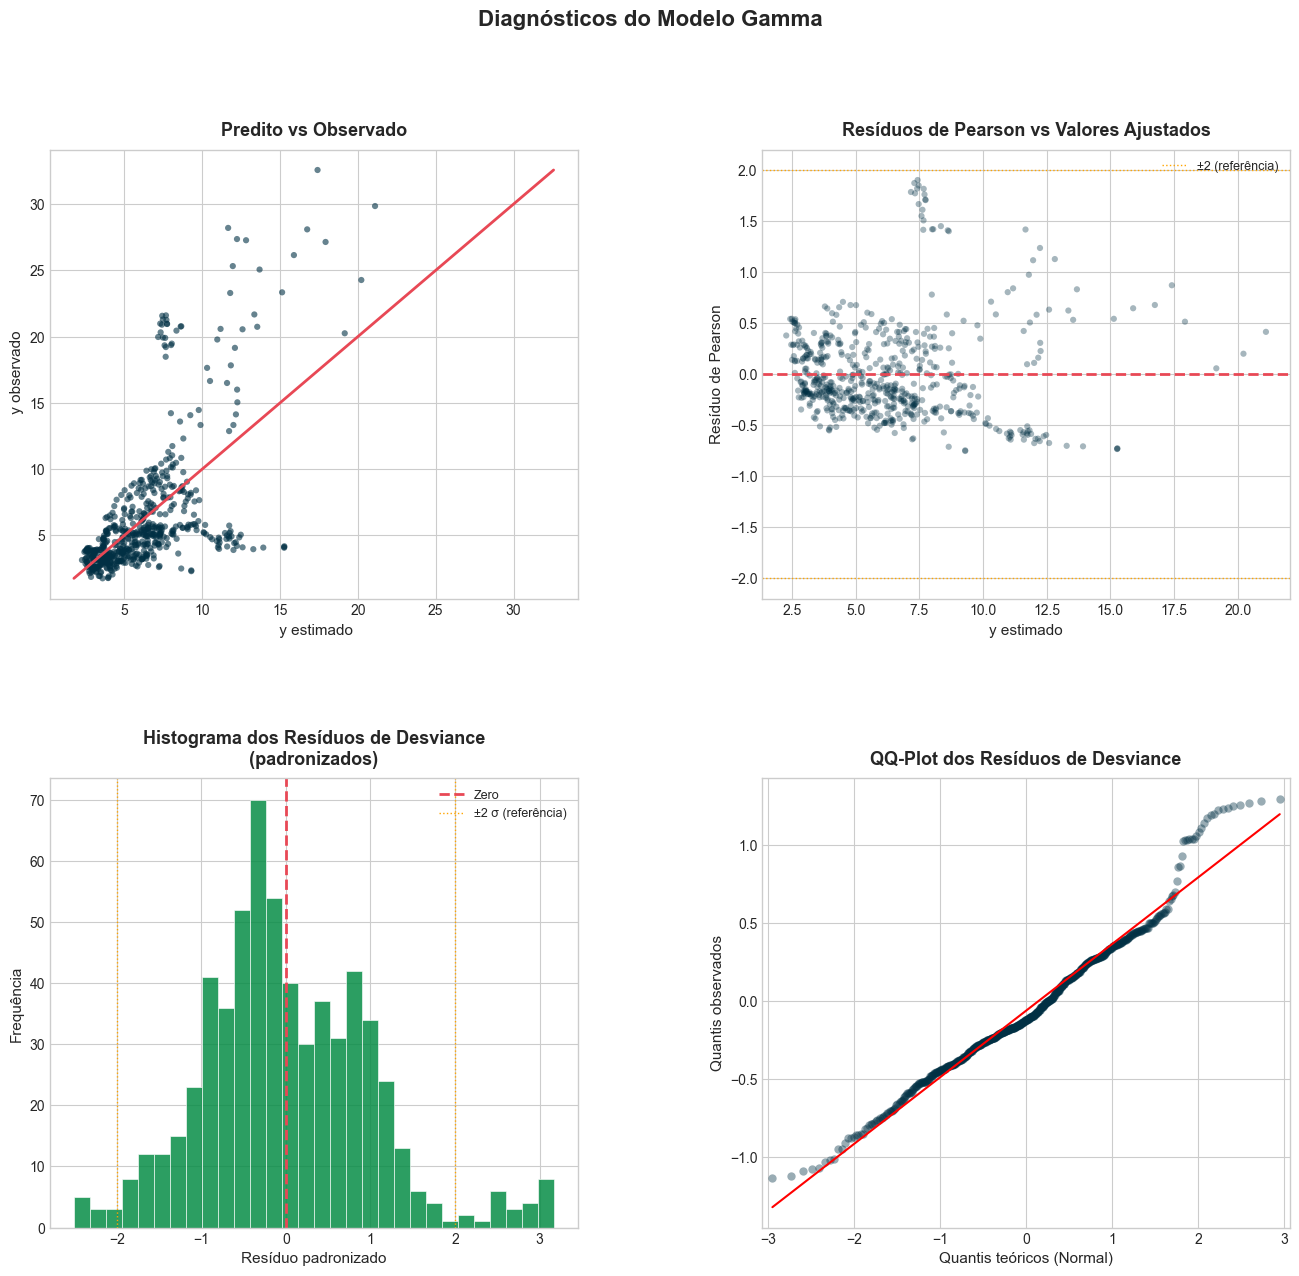

In [159]:
import matplotlib.gridspec as gridspec
from scipy import stats



y = df_energy_filtrado["intensidade_energia_mj_por_pib_ppp"].values # y = valores OBSERVADOS (contagem de projetos)
yhat = modelo.mu # yhat = valores preditos pelo modelo (média esperada de y)
resid_pearson = modelo.resid_pearson # resíduos de Pearson
resid_deviance = modelo.resid_deviance # resíduos deviance
resid_deviance_std = stats.zscore(resid_deviance)


plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    "Diagnósticos do Modelo Gamma",
    fontsize=16, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

cores = {
    "pontos": "#013044",
    "linha":  "#E84855",
    "barra":  "#078D46",
    "fundo":  "#F7F7F7"
}

# GRÁFICO 1 — PREDITO vs OBSERVADO (yhat vs y)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(
    yhat, y,
    alpha=0.6, color=cores["pontos"], edgecolors="none", s=20
)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], color=cores["linha"], linewidth=2)
ax1.set_title("Predito vs Observado", fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel(" y estimado", fontsize=11)
ax1.set_ylabel(" y observado", fontsize=11)

# GRÁFICO 2 — RESÍDUOS DE PEARSON vs VALORES AJUSTADOS

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(
    yhat, resid_pearson,
    alpha=0.35, color=cores["pontos"], edgecolors="none", s=20
)
ax2.axhline(0, color=cores["linha"], linewidth=2, linestyle="--")
ax2.axhline(2,  color="orange", linewidth=1, linestyle=":", label="±2 (referência)")
ax2.axhline(-2, color="orange", linewidth=1, linestyle=":")

ax2.set_title("Resíduos de Pearson vs Valores Ajustados", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("y estimado", fontsize=11)
ax2.set_ylabel("Resíduo de Pearson", fontsize=11)
ax2.legend(fontsize=9)

# GRÁFICO 3 — HISTOGRAMA DOS RESÍDUOS DE DESVÂNCIA

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(
    resid_deviance_std,
    bins=30,
    color=cores["barra"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85
)
ax3.axvline(0, color=cores["linha"], linewidth=2, linestyle="--", label="Zero")
ax3.axvline(-2, color="orange", linewidth=1, linestyle=":", label="±2 σ (referência)")
ax3.axvline(2,  color="orange", linewidth=1, linestyle=":")

ax3.set_title("Histograma dos Resíduos de Desviance\n(padronizados)", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("Resíduo padronizado", fontsize=11)
ax3.set_ylabel("Frequência", fontsize=11)
ax3.legend(fontsize=9)

# GRÁFICO 4 — QQ-PLOT DOS RESÍDUOS DE DESVÂNCIA

ax4 = fig.add_subplot(gs[1, 1])
from statsmodels import graphics
graphics.gofplots.qqplot(resid_deviance, line="r", ax=ax4, alpha=0.4,
                         markerfacecolor=cores["pontos"],
                         markeredgecolor="none")
ax4.set_title("QQ-Plot dos Resíduos de Desviance", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("Quantis teóricos (Normal)", fontsize=11)
ax4.set_ylabel("Quantis observados", fontsize=11)



### Predito vs Observado

Observa-se que a maioria dos pontos está concentrada em valores baixos, indicando que o modelo consegue capturar bem os países com menor intensidade energética. Alguns pontos com valores altos estão acima da linha de 45°, sugerindo que o modelo tende a subestimar a intensidade energética em países com valores muito elevados.

### Resíduos de Pearson vs Valores Ajustados
Há uma dispersão relativamente homogênea dos resíduos ao longo dos valores ajustados, o que é esperado em modelos Gamma. Alguns resíduos estão próximos de ±2, confirmando a presença de observações com intensidade energética inesperadamente alta em relação ao que o modelo prevê.

### Histograma dos Resíduos Desviance

A distribuição é ligeiramente assimétrica à direita, sugerindo a presença de valores extremos — países com intensidade energética muito elevada. A maioria dos resíduos está concentrada dentro de ±2 desvios, mas as caudas longas reforçam a necessidade de atenção às observações influentes identificadas anteriormente.

### QQ-Plot dos Resíduos Desviance

A parte central segue aproximadamente a linha teórica, indicando um ajuste razoável do modelo. Nas extremidades, no entanto, há desvios, indicando que os resíduos não seguem perfeitamente a distribuição esperada. Isso é comum em modelos Gamma quando há observações com valores muito discrepantes, como os países identificados na análise de influência.

### serão usadas três métricas:

* Resíduo studentizado/padronizado — mede o quão mal o modelo prevê aquela observação. Um valor grande indica que o ponto é um outlier na variável resposta (Y).
  
* Leverage (alavancagem) — mede o quão "extrema" é a observação em termos das variáveis preditoras (X). Um ponto com leverage alto fica longe do centro dos dados, tendo potencial para influenciar o modelo.
  
* Distância de Cook — combina os dois anteriores. Mede o impacto real daquela observação nos coeficientes estimados. É a métrica mais importante para identificar influênci

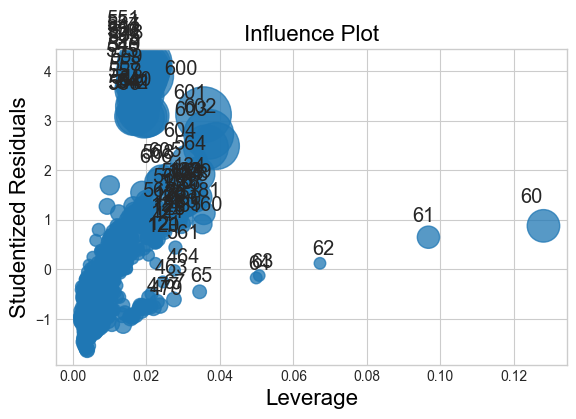

In [160]:
infl = modelo.get_influence(observed=True)
fig = infl.plot_influence(size = 40)
fig.tight_layout(pad=3.0)


Percebemos que há uma parcela de observações com leverage, ou seja, pontos de alavancagem relativamente altos. Além disso, observa-se uma grande concentração de valores entre 0 e 0,04, acompanhada de resíduos studentizados muito elevados. Isso já é um indício de que temos diversas observações que podem estar influenciando excessivamente o ajuste do modelo, prejudicando sua estabilidade e qualidade inferencial.

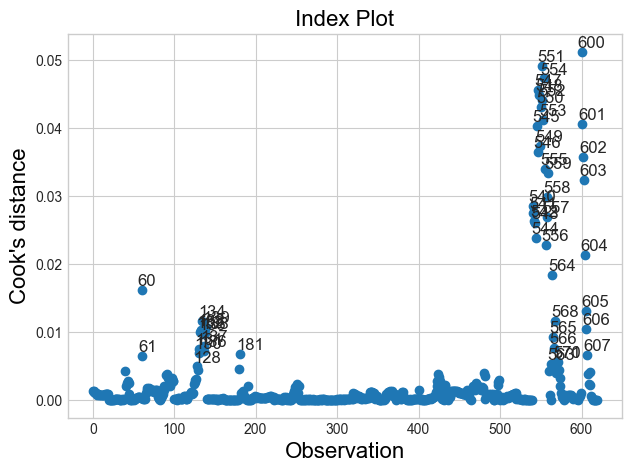

In [161]:
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean())
fig.tight_layout(pad=1.0)

Com o mesmo propósito de identificar observações excessivamente problemáticas, optou-se pela visualização da Distância de Cook. Por meio desse gráfico, é possível identificar claramente dois clusters de observações influentes que impactam de forma considerável a estimação dos parâmetros do modelo. Com base nessa análise, foram removidas apenas as observações que apresentaram simultaneamente uma Distância de Cook elevada e resíduos studentizados altos, por serem as que de fato comprometem a qualidade do ajuste.

In [162]:
infl = modelo.get_influence(observed=True)

# Calcular métricas
cooks_d = infl.cooks_distance[0]
leverage = infl.hat_matrix_diag
resid_student = infl.resid_studentized

# Thresholds
threshold_cooks = 4 / len(df_energy_filtrado)
threshold_resid = 3
threshold_leverage = 2 * modelo.df_model / len(df_energy_filtrado)

# Identificar pontos influentes
mask = (
    (cooks_d > threshold_cooks) |
    (np.abs(resid_student) > threshold_resid) |
    (leverage > threshold_leverage)
)

idx_remover = df_energy_filtrado.index[mask]
print(f"Removendo {len(idx_remover)} observações: {list(idx_remover)}")

# Remover e reajustar
df_energy_filtrado = df_energy_filtrado.drop(index=idx_remover)

modelo = smf.glm(
    formula,
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()


modelo.summary()

Removendo 97 observações: [40, 41, 42, 43, 60, 61, 62, 63, 64, 65, 66, 67, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 180, 181, 182, 184, 191, 253, 380, 381, 425, 426, 427, 428, 461, 462, 463, 464, 475, 476, 477, 478, 479, 480, 481, 483, 501, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 600, 601, 602, 603, 604, 605, 606, 607]


<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                  523
Model:                                            GLM   Df Residuals:                      516
Model Family:                                   Gamma   Df Model:                            6
Link Function:                                    Log   Scale:                         0.10877
Method:                                          IRLS   Log-Likelihood:                -929.01
Date:                                seg, 23 fev 2026   Deviance:                       50.783
Time:                                        14:58:41   Pearson chi2:                     56.1
No. Iterations:                                    13   Pseudo R-squ. (CS):             0.5612
Covariance Type:                            nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    1.5991      0.859      1.862      0.063      -0.084       3.283
pct_energia_renovaveis_primaria             -0.2605      0.023    -11.181      0.000      -0.306      -0.215
pib_per_capita                              -0.1039      0.019     -5.528      0.000      -0.141      -0.067
capacidade_eletrica_renovavel_per_capita     0.0061      0.015      0.412      0.681      -0.023       0.035
pct_acesso_eletricidade                      0.2293      0.196      1.170      0.242      -0.155       0.613
densidade_populacional                      -0.1025      0.012     -8.441      0.000      -0.126      -0.079
co2_emissoes_tm_per_capita                   0.0577      0.015      3.886      0.000       0.029       0.087
============================================================================================================
"""

In [166]:
modelo = smf.glm(
    formula + "- capacidade_eletrica_renovavel_per_capita"
            + "- pct_acesso_eletricidade",
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                  523
Model:                                            GLM   Df Residuals:                      518
Model Family:                                   Gamma   Df Model:                            4
Link Function:                                    Log   Scale:                         0.11011
Method:                                          IRLS   Log-Likelihood:                -930.47
Date:                                seg, 23 fev 2026   Deviance:                       51.011
Time:                                        14:59:54   Pearson chi2:                     57.0
No. Iterations:                                    12   Pseudo R-squ. (CS):             0.5550
Covariance Type:                            nonrobust                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           2.5652      0.243     10.536      0.000       2.088       3.042
pct_energia_renovaveis_primaria    -0.2520      0.014    -18.600      0.000      -0.279      -0.225
pib_per_capita                     -0.0903      0.015     -6.110      0.000      -0.119      -0.061
densidade_populacional             -0.1089      0.011     -9.778      0.000      -0.131      -0.087
co2_emissoes_tm_per_capita          0.0574      0.014      3.972      0.000       0.029       0.086
===================================================================================================
"""

In [171]:
np.exp(modelo.params). round(2) 

Intercept                          13.00
pct_energia_renovaveis_primaria     0.78
pib_per_capita                      0.91
densidade_populacional              0.90
co2_emissoes_tm_per_capita          1.06
dtype: float64

In [172]:
#logit.params
from matplotlib.pylab import exp #ou
import numpy as np
exp(modelo.conf_int(alpha=0.05)).round(2)


,0,1
Intercept,8.07,20.96
pct_energia_renovaveis_primaria,0.76,0.80
pib_per_capita,0.89,0.94
densidade_populacional,0.88,0.92
co2_emissoes_tm_per_capita,1.03,1.09


### Por que utilizar a função `exp` para interpretar os intervalos de confiança?

No modelo de regressão Gamma com link log, os coeficientes estimados (coef) estão na escala logarítmica. Essa escala não é diretamente interpretável em termos da variável resposta original. Para interpretar os coeficientes de forma mais intuitiva, é necessário transformá-los de volta para a escala original, o que é feito aplicando a função exponencial (`exp`), obtendo assim a razão de médias (mean ratio) sobre a média esperada da intensidade energética.

* O fator multiplicativo para **pct_energia_renovaveis_primaria** é aproximadamente 0.78, com um intervalo de confiança de aproximadamente [0.76, 0.80]. Isso significa que, para cada aumento de 1 ponto percentual na participação de energia renovável primária, a média esperada da intensidade energética diminui em cerca de 22%, mantendo as outras variáveis constantes.

* O fator multiplicativo para **pib_per_capita** é aproximadamente 0.91, com um intervalo de confiança de aproximadamente [0.89, 0.94]. Isso significa que, para cada aumento de 1 unidade no PIB per capita, a média esperada da intensidade energética diminui em cerca de 9%, mantendo as outras variáveis constantes.

* O fator multiplicativo para **densidade_populacional** é aproximadamente 0.90, com um intervalo de confiança de aproximadamente [0.88, 0.92]. Isso significa que, para cada aumento unitário na densidade populacional, a média esperada da intensidade energética diminui em cerca de 10%, mantendo as outras variáveis constantes.

* O fator multiplicativo para **co2_emissoes_tm_per_capita** é aproximadamente 1.06, com um intervalo de confiança de aproximadamente [1.03, 1.09]. Isso indica que cada aumento unitário nas emissões de CO₂ per capita eleva a média esperada da intensidade energética em cerca de 6%, mantendo as outras variáveis constantes.